## Phase 1: Multi-Head Attention (MHA) — The Expensive Office

Let's use a corporate office analogy.

* **The Queries (Q):** These are the Executives. They ask questions. Let's say we have 32 Executives.
* **The Keys & Values (K, V):** These are the Filing Cabinets. They hold the memory of the conversation.

In standard MHA, every single Executive gets their own personal, dedicated Filing Cabinet.

**Ratio:** 32 Queries : 32 KV Caches.

* **The Pros:** Maximum intelligence. Every executive organizes their memory exactly how they want it.
* **The Cons (The Crisis):** Office space (VRAM) is completely maxed out. Rent is too high. The server crashes.

---

## Phase 2: Multi-Query Attention (MQA) — The Extreme Overcorrection

A few years ago, researchers panicked about the VRAM crisis and invented MQA (Multi-Query Attention). Used in some older models like Falcon, this was an extreme cost-cutting measure.

They fired 31 of the assistants and threw away 31 filing cabinets.

**Ratio:** 32 Queries : 1 KV Cache.

All 32 independent Executives are forced to share exactly one communal filing cabinet.

* **The Pros:** Memory usage drops by 97%. The Blue Line completely flatlines. It is incredibly fast and cheap.
* **The Cons:** A massive intelligence drop. If the Grammar Executive, the Tone Executive, and the Logic Executive all have to pull from the exact same generic memory file, the model loses its nuance and starts hallucinating or writing poorly.

---

## Phase 3: Grouped Query Attention (GQA) — The Goldilocks Solution

In 2023, researchers realized that MHA was too expensive, and MQA was too stupid. They found the perfect middle ground: **Grouped Query Attention**.

Instead of 1 cabinet for everyone, or 32 personal cabinets... what if we group the executives into **Departments**?

**Ratio (Llama 3 8B example):** 32 Queries : 8 KV Caches.

Every 4 Executives share 1 Filing Cabinet.
* Heads 1, 2, 3, 4 (maybe the "Linguistics Department") share **KV Cache A**.
* Heads 5, 6, 7, 8 (maybe the "Logic Department") share **KV Cache B**.
* ...and so on.

### Why GQA is a Masterpiece:
* **Memory:** We just reduced the KV Cache size by 75% (from 32 down to 8). We saved Gigabytes of VRAM.
* **Speed:** Less memory to load means the GPU processes the text faster.
* **Intelligence:** Surprisingly, researchers found that models trained with GQA are almost identically as smart as models trained with standard MHA. Sharing a cabinet with 3 co-workers doesn't ruin your workflow nearly as much as sharing it with 31.

---

## The Mathematical Mechanism: "Broadcasting"

How does the math actually work if the shapes don't match? If we have 4 Queries but only 1 Key... how do they multiply?

This is where the tensor gymnastics get beautifully efficient through a process called **Broadcasting**.

Imagine the Attention Math for Group 1:
* We have 4 distinct Query vectors: $Q_1, Q_2, Q_3, Q_4$.
* We have 1 shared Key vector: $K_A$.
* The GPU simply copies (broadcasts) $K_A$ four times in a fraction of a millisecond.

| Step | Operation | Result |
|------|-----------|--------|
| 1 | $Q_1$ compares itself to $K_A$ | Score 1 |
| 2 | $Q_2$ compares itself to $K_A$ | Score 2 |
| 3 | $Q_3$ compares itself to $K_A$ | Score 3 |
| 4 | $Q_4$ compares itself to $K_A$ | Score 4 |

They all get their own unique attention scores because their Queries ($Q$) are still uniquely theirs. They are just evaluating the same baseline memory ($K$).

# Is it removing the dimensions or how??

The dimension of each individual head (e.g., 64) stays **exactly the same**. The mathematical "resolution" of the vector doesn't shrink.

What we reduce is the **number of vectors**.

* Instead of generating **32** full-size Keys, we only generate **8** full-size Keys.
* Then, groups of 4 Queries simply share and read from those exact same 8 full-size Keys.

> You aren't shrinking the size of the paper; you are just printing fewer copies!

# output still reamains same 32 even after K,V are compressed to 8 right why?

Here is exactly how those 32 new vectors are born using the first group (Queries 1–4 sharing KV 1):

| Query | Recipe (Attention Scores) | Result |
|-------|---------------------------|--------|
| Query 1 | "90% of Value A, 10% of Value B" | $\to$ Unique Output 1 |
| Query 2 | "20% of Value A, 80% of Value B" | $\to$ Unique Output 2 |
| Query 3 | "50% of Value A, 50% of Value B" | $\to$ Unique Output 3 |
| Query 4 | "0% of Value A, 100% of Value B" | $\to$ Unique Output 4 |

They mixed the exact same raw ingredients ($V$), but because they used **different recipes** (the Attention Scores from $Q \times K$), they baked 4 completely different cakes.

### The Full Circle

So what happens to those 32 brand new, unique outputs?

We do exactly what we did in standard Multi-Head Attention! We line all 32 of them up side-by-side (the `.view()` smush), and we pass them through the **Final Output Projection Blender** ($W_o$).

This is why GQA is a masterpiece:

| Stage | Details |
|-------|---------|
| **Input** | 32 Queries, 8 Keys, 8 Values (Saves 75% of VRAM!) |
| **Math** | 32 different attention calculations happen |
| **Output** | 32 distinct, intelligent results come out the other side |

> You get the VRAM savings of a small cache, but the intelligence output of a massive 32-head model.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model=2048, num_q_heads=32, num_kv_heads=8):
        super().__init__()
        self.num_q_heads = num_q_heads
        self.num_kv_heads = num_kv_heads
        self.num_groups = num_q_heads // num_kv_heads # 32 / 8 = 4
        self.head_dim = d_model // num_q_heads # 2048 / 32 = 64
        
        print(f"--- INITIALIZING GQA ---")
        print(f"Total Q Heads:  {self.num_q_heads}")
        print(f"Total KV Heads: {self.num_kv_heads} (This is the VRAM saving!)")
        print(f"Group Size:     {self.num_groups} Qs sharing 1 KV\n")
        
        # The Blenders
        self.w_q = nn.Linear(d_model, num_q_heads * self.head_dim, bias=False)
        self.w_k = nn.Linear(d_model, num_kv_heads * self.head_dim, bias=False)
        self.w_v = nn.Linear(d_model, num_kv_heads * self.head_dim, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        print(f"[Step 0] Input Shape:         {x.shape} -> (Batch, Tokens, Dim)")
        
        # --- 1. The Blenders ---
        q = self.w_q(x)
        k = self.w_k(x)
        v = self.w_v(x)
        print(f"[Step 1] After Q Blender:     {q.shape} -> (Batch, Tokens, 2048)")
        print(f"[Step 1] After K Blender:     {k.shape}  -> (Batch, Tokens, 512) <-- Shrunk!")
        
        # --- 2. Slice and Swap ---
        q = q.view(B, T, self.num_q_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
        print(f"[Step 2] Swapped Q:           {q.shape} -> 32 Heads")
        print(f"[Step 2] Swapped K:           {k.shape}  -> 8 Heads")
        
        # --- 3. The 'Decompression' (repeat_interleave) ---
        # We copy-paste the 8 K and V heads 4 times each so they match the 32 Q heads.
        k_expanded = k.repeat_interleave(self.num_groups, dim=1)
        v_expanded = v.repeat_interleave(self.num_groups, dim=1)
        print(f"[Step 3] Decompressed K:      {k_expanded.shape} -> Back to 32 Heads for math!")
        
        # --- 4. Parallel Attention Math ---
        scores = torch.matmul(q, k_expanded.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = torch.tril(torch.ones(T, T)).to(x.device)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(scores, dim=-1)
        print(f"[Step 4] Attention Weights:   {attn_weights.shape} -> 32 Unique Score Grids!")
        
        # Apply weights to Values
        out = torch.matmul(attn_weights, v_expanded)
        print(f"[Step 5] Head Outputs:        {out.shape} -> 32 Unique Output Vectors!")
        
        # --- 5. Reassembly ---
        out = out.transpose(1, 2).contiguous().view(B, T, self.num_q_heads * self.head_dim)
        print(f"[Step 6] Smushed Output:      {out.shape} -> Back to 2048")
        
        out = self.w_o(out)
        print(f"[Step 7] Final Output:        {out.shape} -> Fully Blended")
        
        return out

if __name__ == "__main__":
    dummy_input = torch.randn(1, 10, 2048) # 1 Batch, 10 Tokens, 2048 Dim
    gqa = GroupedQueryAttention()
    final_output = gqa(dummy_input)
    print("\n✅ SUCCESS: 32 Queries successfully shared 8 KV Heads!")

--- INITIALIZING GQA ---
Total Q Heads:  32
Total KV Heads: 8 (This is the VRAM saving!)
Group Size:     4 Qs sharing 1 KV

[Step 0] Input Shape:         torch.Size([1, 10, 2048]) -> (Batch, Tokens, Dim)
[Step 1] After Q Blender:     torch.Size([1, 10, 2048]) -> (Batch, Tokens, 2048)
[Step 1] After K Blender:     torch.Size([1, 10, 512])  -> (Batch, Tokens, 512) <-- Shrunk!
[Step 2] Swapped Q:           torch.Size([1, 32, 10, 64]) -> 32 Heads
[Step 2] Swapped K:           torch.Size([1, 8, 10, 64])  -> 8 Heads
[Step 3] Decompressed K:      torch.Size([1, 32, 10, 64]) -> Back to 32 Heads for math!
[Step 4] Attention Weights:   torch.Size([1, 32, 10, 10]) -> 32 Unique Score Grids!
[Step 5] Head Outputs:        torch.Size([1, 32, 10, 64]) -> 32 Unique Output Vectors!
[Step 6] Smushed Output:      torch.Size([1, 10, 2048]) -> Back to 2048
[Step 7] Final Output:        torch.Size([1, 10, 2048]) -> Fully Blended

✅ SUCCESS: 32 Queries successfully shared 8 KV Heads!


Calculating memory footprints...
Generating plot...


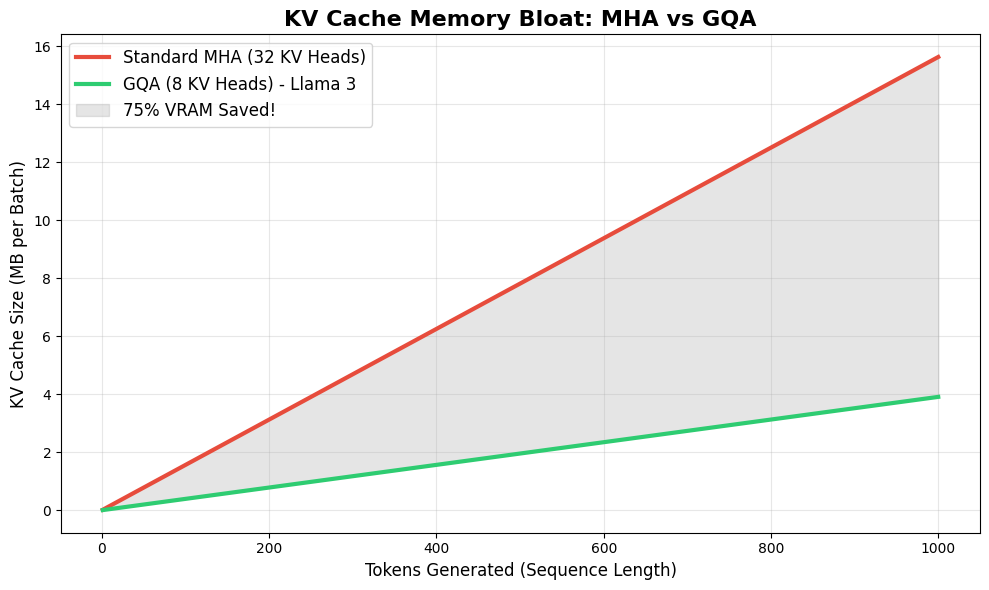

In [3]:
import matplotlib.pyplot as plt

def plot_memory_savings():
    print("Calculating memory footprints...")
    seq_len = 1000
    batch_size = 1
    d_model = 2048
    head_dim = 64
    
    # MHA: 32 KV Heads
    mha_kv_heads = 32
    # GQA: 8 KV Heads (Llama 3 style)
    gqa_kv_heads = 8
    
    mha_memory_mb = []
    gqa_memory_mb = []
    
    for tokens in range(1, seq_len + 1):
        # Formula: 2 (for K and V) * batch * tokens * heads * head_dim * 4 bytes (float32)
        mha_bytes = 2 * batch_size * tokens * mha_kv_heads * head_dim * 4
        gqa_bytes = 2 * batch_size * tokens * gqa_kv_heads * head_dim * 4
        
        mha_memory_mb.append(mha_bytes / (1024 * 1024))
        gqa_memory_mb.append(gqa_bytes / (1024 * 1024))
    
    print("Generating plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, seq_len + 1), mha_memory_mb, label='Standard MHA (32 KV Heads)', color='#e74c3c', linewidth=3)
    plt.plot(range(1, seq_len + 1), gqa_memory_mb, label='GQA (8 KV Heads) - Llama 3', color='#2ecc71', linewidth=3)
    
    plt.fill_between(range(1, seq_len + 1), mha_memory_mb, gqa_memory_mb, color='gray', alpha=0.2, label='75% VRAM Saved!')
    
    plt.title("KV Cache Memory Bloat: MHA vs GQA", fontsize=16, fontweight='bold')
    plt.xlabel("Tokens Generated (Sequence Length)", fontsize=12)
    plt.ylabel("KV Cache Size (MB per Batch)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()

if __name__ == "__main__":
    plot_memory_savings()